# Data Formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct, HD_zip]).iloc[:, 1:10]
acs_all = pd.concat([acs_ct, acs_zip])

In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

In [ ]:
# CSV
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)

cum_df_12 = df_combined[[24,'GEOID']].copy()
cum_df_12 = cum_df_12.rename(columns={24: 'cum_att'})
cum_df_12["GEOID"] = cum_df_12["GEOID"].astype(str)

In [ ]:
# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on="GEOID", how="left") \
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
df_disdecall = pd.read_csv("/mnt/drive/MyDrive/Colab_data/DisasterDeclarationsSummaries.csv")

dec = pd.merge(dec, df_disdecall, left_on='disasterNumber', right_on='disasterNumber', how='left').copy()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# ATT Regression

## Regression Plot

In [ ]:
# --- Remove Inf and drop missing ---
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan)

y_clean = merged_df_clean["cum_att"].astype(float)

# Independent variables
merged_df_clean['D_TH'] = merged_df_clean['Tre_p']
merged_df_clean['Black_Population_Ratio'] = merged_df_clean['Black_Population'] / merged_df_clean['Total_Population']
merged_df_clean['zip'] = merged_df_clean['GEOID'].apply(lambda x: 1 if len(str(x)) == 5 else 0)


In [ ]:
merged_df_clean = merged_df_clean[merged_df_clean["city_y"] != "Richmond, VA"]

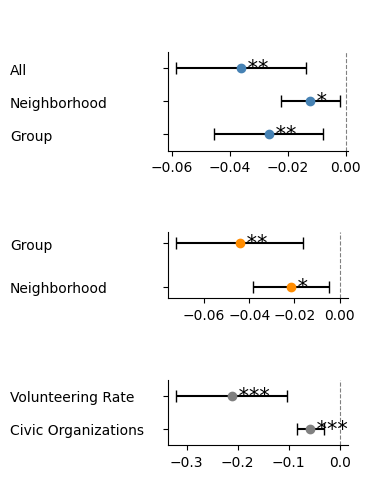

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
x_vars = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_bias_high_zip",
    "nbhd_bias_zip",
    "bias_grp_mem_high_zip",
    "bias_grp_mem_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_high_zip",
    "exposure_grp_mem_zip",
    "ec_grp_mem_high_zip",
    "nbhd_ec_high_zip",
    "ec_high_zip",
    "ec_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_zip"
]

x_vars_plot = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_grp_mem_zip",
    "ec_zip"
]


control_vars = [
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
    "disasterNumber",
    "D_TH"
]

y_var = "cum_att"

x_label_mapping = {
    "civic_organizations_zip": "Civic Organizations",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Friending Bias (high SE)",
    "nbhd_bias_zip": "Neighborhood\n Friending Bias",
    "bias_grp_mem_high_zip": "Group Friending Bias (high SE)",
    "bias_grp_mem_zip": "Group Friending Bias",
    "nbhd_exposure_zip": "Neighborhood",
    "exposure_grp_mem_high_zip": "Group Exposure (high SE)",
    "exposure_grp_mem_zip": "Group",
    "ec_grp_mem_high_zip": "Group Econ Connectedness (high SE)",
    "nbhd_ec_high_zip": "Neighborhood Econ Connectedness (high SE)",
    "ec_high_zip": "Economic Connectedness (high SE)",
    "nbhd_ec_zip": "Neighborhood",
    "ec_grp_mem_zip": "Group",
    "ec_zip": "All",
}

# --- Category ---
def get_category(var_name):
    if "ec" in var_name:
        return "economic connectedness"
    elif "exposure" in var_name:
        return "exposure"
    elif "bias" in var_name:
        return "friending bias"
    else:
        return "civic engagement"

color_mapping = {
    "economic connectedness": "steelblue",
    "exposure": "darkorange",
    "friending bias": "seagreen",
    "civic engagement": "grey"
}

# ==============================
# Regression
# ==============================
def run_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    cluster_var="disasterNumber"
):
    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:
        # =========================
        # Subset
        # =========================
        cols = [y_var, x] + controls
        df_sub = df[cols].copy()

        # =========================
        # numeric coercion
        # =========================
        df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
        df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # =========================
        # y / X
        # =========================
        y = df_sub[y_var].astype(float)
        X = df_sub.drop(columns=[y_var])

        # =========================
        # Explicit FE handling
        # =========================
        if "disasterNumber" in X.columns:
            X["disasterNumber"] = X["disasterNumber"].astype("category")

        if "zip" in X.columns:
            X["zip"] = X["zip"].astype("category")

        # =========================
        # Dummy
        # =========================
        X = pd.get_dummies(X, drop_first=True)

        X = X.astype(float)

        X = sm.add_constant(X, has_constant="add")

        # =========================
        # Cluster
        # =========================
        groups = df_sub[cluster_var]

        model = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups}
        )
        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        results.append({
            "x_variable": x,
            "Coefficient": model.params[x],
            "CI_Lower": model.conf_int().loc[x, 0],
            "CI_Upper": model.conf_int().loc[x, 1],
            "p_value": model.pvalues[x]
        })

    return pd.DataFrame(results),regression_results, latex_results


# --- Plot ---
def plot_coefficients_by_category(df):
    df["category"] = df["x_variable"].apply(get_category)
    categories = list(df["category"].unique())[::-1]

    height_ratios = [len(df[df["category"] == cat]) for cat in categories]

    global_min = df["CI_Lower"].min()-0.05
    global_max = df["CI_Upper"].max()+0.05

    fig = plt.figure(figsize=(3.8, sum(height_ratios)*0.7))
    gs = gridspec.GridSpec(len(categories), 1, height_ratios=height_ratios)

    for idx, cat in enumerate(categories):
        ax = fig.add_subplot(gs[idx])
        sub_df = df[df["category"] == cat]

        for i, row in sub_df.iterrows():
            color = color_mapping.get(cat, "black")
            ci_lower = row["Coefficient"] - row["CI_Lower"]
            ci_upper = row["CI_Upper"] - row["Coefficient"]

            # significance star
            if row["p_value"] < 0.001:
                signif = "***"
            elif row["p_value"] < 0.01:
                signif = "**"
            elif row["p_value"] < 0.05:
                signif = "*"
            elif row["p_value"] < 0.1:
                signif = "†"
            else:
                signif = ""

            ax.errorbar(
                row["Coefficient"], i,
                xerr=[[ci_lower], [ci_upper]],
                fmt="o", color=color, ecolor="black",
                capsize=4, markersize=6
            )

            if signif:
                ax.text(row["Coefficient"], i, " " + signif,
                        va="center", fontsize=15)

        ax.set_title(cat.capitalize(), fontsize=1, color="white", loc = "left", pad = 30)
        ax.set_yticks(sub_df.index)
        ax.set_yticklabels([x_label_mapping.get(v, v) for v in sub_df["x_variable"]],fontsize=10,ha="left")
        ax.tick_params(axis='y', pad=110)


        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)

        ymin = sub_df.index.min() - 0.5
        ymax = sub_df.index.max() + 0.5
        ax.set_ylim(ymin, ymax)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


    plt.tight_layout()
    plt.savefig("figure.png", dpi=200, bbox_inches="tight")
    plt.show()

df_controls, regression_results, latex_results = run_regression(
    merged_df_clean,
    x_vars,
    controls=control_vars
)
coef_df_plot = df_controls[df_controls["x_variable"].isin(x_vars_plot)].copy()

plot_coefficients_by_category(coef_df_plot)

from google.colab import files
files.download("figure.png")

In [ ]:
for var, model in regression_results.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     10.17
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           7.36e-05
Time:                        16:10:28   Log-Likelihood:                 4501.8
No. Observations:                2302   AIC:                            -8954.
Df Residuals:                    2277   BIC:                            -8810.
Df Model:                          24                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

In [ ]:
use_cols = x_vars + control_vars + [y_var]

df_used = merged_df_clean[use_cols].copy()

df_used = df_used.dropna(subset=control_vars)

desc_stats = df_used.describe()

desc_stats_t = desc_stats.T.iloc[::-1]

latex_table = desc_stats_t.to_latex(float_format="%.3f", index=True)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cum_att & 2306.000 & -0.015 & 0.036 & -0.188 & -0.033 & -0.014 & 0.002 & 0.282 \\
D_TH & 2306.000 & 0.008 & 0.018 & 0.000 & 0.000 & 0.001 & 0.006 & 0.299 \\
disasterNumber & 2306.000 & 4560.401 & 431.733 & 1650.000 & 4609.000 & 4673.000 & 4675.000 & 4751.000 \\
Renter_Households & 2306.000 & 2691.769 & 5669.825 & 5.000 & 412.000 & 719.000 & 1279.250 & 29069.000 \\
Black_Population_Ratio & 2306.000 & 0.282 & 0.275 & 0.000 & 0.059 & 0.181 & 0.434 & 1.000 \\
Median_Household_Income & 2306.000 & 68849.594 & 33146.269 & 2499.000 & 45455.000 & 61324.500 & 84411.000 & 233542.000 \\
ec_zip & 2300.000 & 0.779 & 0.203 & 0.377 & 0.612 & 0.767 & 0.905 & 1.359 \\
nbhd_ec_zip & 2247.000 & 0.705 & 0.375 & 0.095 & 0.414 & 0.646 & 0.907 & 1.859 \\
ec_grp_mem_zip & 2293.000 & 0.856 & 0.247 & 0.351 & 0.668 & 0.845 & 1.012 & 1.579 \\
ec_high_zip & 2300.000 & 1.343 & 0.205 & 0.830 & 1.206 & 1.354 & 1.500 & 1

In [ ]:
pip install stargazer

In [ ]:
from statsmodels.iolib.summary2 import summary_col
import re

models = [v["model"] for v in reversed(latex_results.values())]

table = summary_col(
    models,
    stars=True,
    model_names=[f"({i})" for i in range(1, len(models)+1)],
    info_dict={
        "Controls": lambda x: "Yes",
        "N": lambda x: f"{int(x.nobs)}",
        "R-squared": lambda x: f"{x.rsquared:.3f}"
    }
)


latex_table = table.as_latex()

latex_table = re.sub(
    r'(-?\d+\.\d+)',
    lambda m: f"{float(m.group()):.3f}",
    latex_table
)

print(latex_table)


\begin{table}
\caption{}
\label{}
\begin{center}
\begin{tabular}{llllllllllllllll}
\hline
                              & (1)        & (2)        & (3)        & (4)        & (5)        & (6)        & (7)        & (8)        & (9)        & (10)       & (11)       & (12)       & (13)       & (14)       & (15)        \\
\hline
const                         & 0.017     & -0.004    & 0.013     & 0.041**   & 0.002     & 0.042*    & 0.031*    & 0.048**   & -0.000    & -0.012    & -0.028*** & -0.013*   & -0.024*** & -0.009    & -0.011     \\
                              & (0.016)   & (0.010)   & (0.015)   & (0.021)   & (0.013)   & (0.022)   & (0.019)   & (0.021)   & (0.011)   & (0.009)   & (0.008)   & (0.007)   & (0.008)   & (0.009)   & (0.009)    \\
ec\_zip                       & -0.036*** &            &            &            &            &            &            &            &            &            &            &            &            &            &             \\
                  

# Shapley R^2

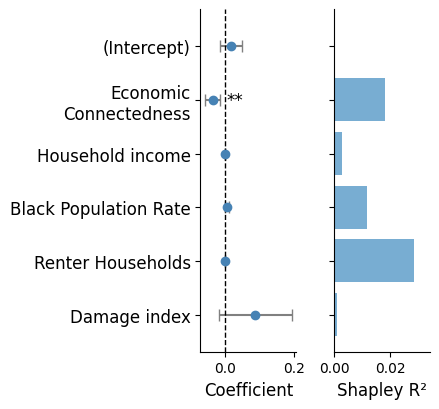

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from collections import defaultdict

# -----------------------------
# 1. Stars
# -----------------------------
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "†"
    else:
        return ""

# -----------------------------
# 2. Labels（この変数だけ表示）
# -----------------------------
var_labels = {
    "const": "(Intercept)",
    "ec_zip": "Economic\nConnectedness",
    "Black_Population_Ratio": "Black Population Rate",
    "Renter_Households": "Renter Households",
    "D_TH": "Damage index",
    "Median_Household_Income": "Household income",
}

vars_to_keep = list(var_labels.keys())

# -----------------------------
# 3. Model
# -----------------------------
model = regression_results["ec_zip"]

coefs = model.params.copy()
conf_int = model.conf_int()
pvals = model.pvalues

# var_labels vars only
coefs = coefs.loc[coefs.index.intersection(vars_to_keep)]
conf_int = conf_int.loc[coefs.index]
pvals = pvals.loc[coefs.index]

coef_names = [var_labels[v] for v in coefs.index]
coef_values = coefs.values
lower = coef_values - conf_int[0].values
upper = conf_int[1].values - coef_values
signif_labels = [significance_stars(p) for p in pvals]

# -----------------------------
# 4. Shapley R²
# -----------------------------
X_full = model.model.exog
y = model.model.endog
exog_names = model.model.exog_names

keep_idx = [
    i for i, v in enumerate(exog_names)
    if (v in vars_to_keep)
]

X = X_full[:, keep_idx]
vars_kept = [exog_names[i] for i in keep_idx]

shapley_r2 = defaultdict(float)
n_samples = 1000
np.random.seed(0)

for _ in range(n_samples):
    perm = np.random.permutation(len(vars_kept))
    current_X = np.ones((len(y), 1))
    r2_prev = 0

    for idx in perm:
        current_X = np.column_stack([current_X, X[:, idx]])
        r2_curr = sm.OLS(y, current_X).fit().rsquared
        shapley_r2[vars_kept[idx]] += r2_curr - r2_prev
        r2_prev = r2_curr

for k in shapley_r2:
    shapley_r2[k] /= n_samples

shapley_r2_list = [
    0 if v == "const" else shapley_r2.get(v, 0)
    for v in coefs.index
]

# -----------------------------
# 5. Plot
# -----------------------------
fig, (ax_coef, ax_r2) = plt.subplots(
    ncols=2, sharey=True,
    figsize=(4.5, len(coef_names) * 0.7)
)

y_pos = np.arange(len(coef_names))

# Coefficients
ax_coef.errorbar(
    coef_values, y_pos,
    xerr=[lower, upper],
    fmt='o', color='steelblue',
    ecolor='gray', capsize=4
)
ax_coef.axvline(0, color='black', linestyle='--', linewidth=1)

for i, s in enumerate(signif_labels):
    if s:
        offset = 0.04
        ax_coef.text(
            coef_values[i] + offset,
            i,
            s,
            va='center',
            fontsize=12
        )

ax_coef.set_xlabel("Coefficient", fontsize=12)
ax_coef.set_yticks(y_pos)
ax_coef.set_yticklabels(coef_names, fontsize=12)
ax_coef.invert_yaxis()
ax_coef.spines['top'].set_visible(False)
ax_coef.spines['right'].set_visible(False)

# Shapley R²
ax_r2.barh(y_pos, shapley_r2_list, alpha=0.6)
ax_r2.set_xlabel("Shapley R²", fontsize=12)
ax_r2.set_xlim(
    0,
    max(shapley_r2_list) * 1.2 if max(shapley_r2_list) > 0 else 0.01
)
ax_r2.spines['top'].set_visible(False)
ax_r2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figure.png", dpi=200)
plt.show()

from google.colab import files
files.download("figure.png")


#TEX

In [ ]:
from statsmodels.iolib.summary2 import summary_col
import re
import math

# ==================================================
# 1. Variable groups
# ==================================================
demographics_vars = {
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
}

damage_index_vars = {
    "D_TH",
}

disaster_fe_prefix = "disaster"

# ==================================================
# 2. Label mapping（表示したい変数のみ）
# ==================================================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Bias (high)",
    "nbhd_bias_zip": "Neighborhood Bias",
    "bias_grp_mem_high_zip": "Group Bias (high)",
    "bias_grp_mem_zip": "Group Bias",
    "nbhd_exposure_zip": "Neighborhood Exp.",
    "exposure_grp_mem_high_zip": "Group Exp. (high)",
    "exposure_grp_mem_zip": "Group Exp.",
    "ec_grp_mem_high_zip": "Group EC (high)",
    "nbhd_ec_high_zip": "Neighborhood EC (high)",
    "ec_high_zip": "EC (high)",
    "nbhd_ec_zip": "Neighborhood EC",
    "ec_grp_mem_zip": "Group EC",
    "ec_zip": "EC",
    "const": "const"
}

target_vars = list(x_label_mapping.keys())

# ==================================================
# 3. Helper functions
# ==================================================
def has_any(model, vars_set):
    return any(v in model.model.exog_names for v in vars_set)

def has_prefix(model, prefix):
    return any(v.startswith(prefix) for v in model.model.exog_names)

# ==================================================
# 4. Build LaTeX table
# ==================================================
def format_latex_table(models, start_idx):

    table = summary_col(
        models,
        stars=True,
        model_names=[f"({i})" for i in range(start_idx, start_idx + len(models))],
        info_dict={
            "Damage index": lambda x: "Yes" if has_any(x, damage_index_vars) else "No",
            "Demographics": lambda x: "Yes" if has_any(x, demographics_vars) else "No",
            "Disaster FE": lambda x: "Yes" if has_prefix(x, disaster_fe_prefix) else "No",
            "N": lambda x: f"{int(x.nobs)}",
            "R-squared": lambda x: f"{x.rsquared:.3f}",
        },
    )

    df = table.tables[0]

    # ----------------------------------------------
    # ① 残す係数＋SE行、集計行を position で決める
    # ----------------------------------------------
    keep_pos = set()
    n = len(df)
    summary_rows = {"R-squared", "R-squared Adj.", "N", "Damage index", "Demographics", "Disaster FE"}

    for i in range(n):
        idx = df.index[i]
        base = re.sub(r"\(.*\)", "", idx).strip()

        # 表示したい変数の係数行
        if base in target_vars:
            keep_pos.add(i)
            if i + 1 < n:
                keep_pos.add(i + 1)  # SE行も保持
        # 集計行は必ず保持
        elif base in summary_rows:
            keep_pos.add(i)

    df = df.iloc[sorted(keep_pos)]

    # ----------------------------------------------
    # ② index をラベルに置換（SE行対応）
    # ----------------------------------------------
    new_index = []
    last_label = ""

    for idx in df.index:
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in x_label_mapping:
            label = x_label_mapping[base]
            last_label = label
        else:
            # SE 行や集計行は index が空でも保持
            if "(" in idx:
                label = f"{last_label} {idx}"
            else:
                label = base

        new_index.append(label)

    df.index = new_index

    # ----------------------------------------------
    # ③ LaTeX 化
    # ----------------------------------------------
    table.tables[0] = df
    latex = table.as_latex()

    # 小さく
    latex = latex.replace(
        r"\begin{table}",
        r"\begin{table}\footnotesize"
    )

    # 数値を 3 桁に
    latex = re.sub(
        r"(-?\d+\.\d+)",
        lambda m: f"{float(m.group()):.3f}",
        latex,
    )

    # 星を ^{\tiny ***} 表記に
    latex = re.sub(
        r"(\*{1,3})",
        r"$^{\\tiny \1}$",
        latex
    )

    return latex

# ==================================================
# 5. Split models into左右2つのテーブル
# ==================================================
models = [v["model"] for v in reversed(latex_results.values())]

mid = math.ceil(len(models) / 2)
models_left = models[:mid]
models_right = models[mid:]

latex_left = format_latex_table(models_left, 1)
latex_right = format_latex_table(models_right, mid + 1)

print(latex_left)
print(latex_right)


\begin{table}\footnotesize
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                       & (1)        & (2)       & (3)        & (4)        & (5)      & (6)        & (7)        & (8)         \\
\hline
const                  & 0.017     & -0.004   & 0.013     & 0.041$^{\tiny **}$   & 0.002   & 0.042$^{\tiny *}$    & 0.031$^{\tiny *}$    & 0.048$^{\tiny **}$    \\
                       & (0.016)   & (0.010)  & (0.015)   & (0.021)   & (0.013) & (0.022)   & (0.019)   & (0.021)    \\
EC                     & -0.036$^{\tiny ***}$ &           &            &            &          &            &            &             \\
                       & (0.011)   &           &            &            &          &            &            &             \\
Neighborhood EC        &            & -0.012$^{\tiny **}$ &            &            &          &            &            &             \\
                       &            & (0.005)  &            &            &        